# Learn BN Structure from Data

This notebook is to demonstrate: given Bayesian Network without dependencies defined, how to learn the dependencies from data.

In [52]:
# install the required packages if not installed before
%pip install bnlearn
%pip install pandas

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [32]:
# Use the well known rain-sprinkler example
import bnlearn as bn

df = bn.import_example("sprinkler")
df

,Cloudy,Sprinkler,Rain,Wet_Grass
0,0,0,0,0
1,1,0,1,1
2,0,1,0,1
3,1,1,1,1
4,1,1,1,1
...,...,...,...,...
995,1,0,1,1
996,1,0,1,1
997,1,0,1,1
998,0,0,0,0


The network looks like this:
![bn](./Multiply-connected-Bayesian-Network-with-CP-Tables-In-this-example-we-can-combine-the.png)

In [37]:
# Fit data into a BN model and learn the structure
# Hillclimbsearch is chosen as the search method here
# since in our case we work on a dataset in a considerable size
model = bn.structure_learning.fit(df, methodtype="hc")

[bnlearn] >Computing best DAG using [hc]
[bnlearn] >Set scoring type at [bic]
[bnlearn] >Compute structure scores for model comparison (higher is better).


[bnlearn] >Set node properties.
[bnlearn] >Set edge properties.
[bnlearn] >Plot based on Bayesian model


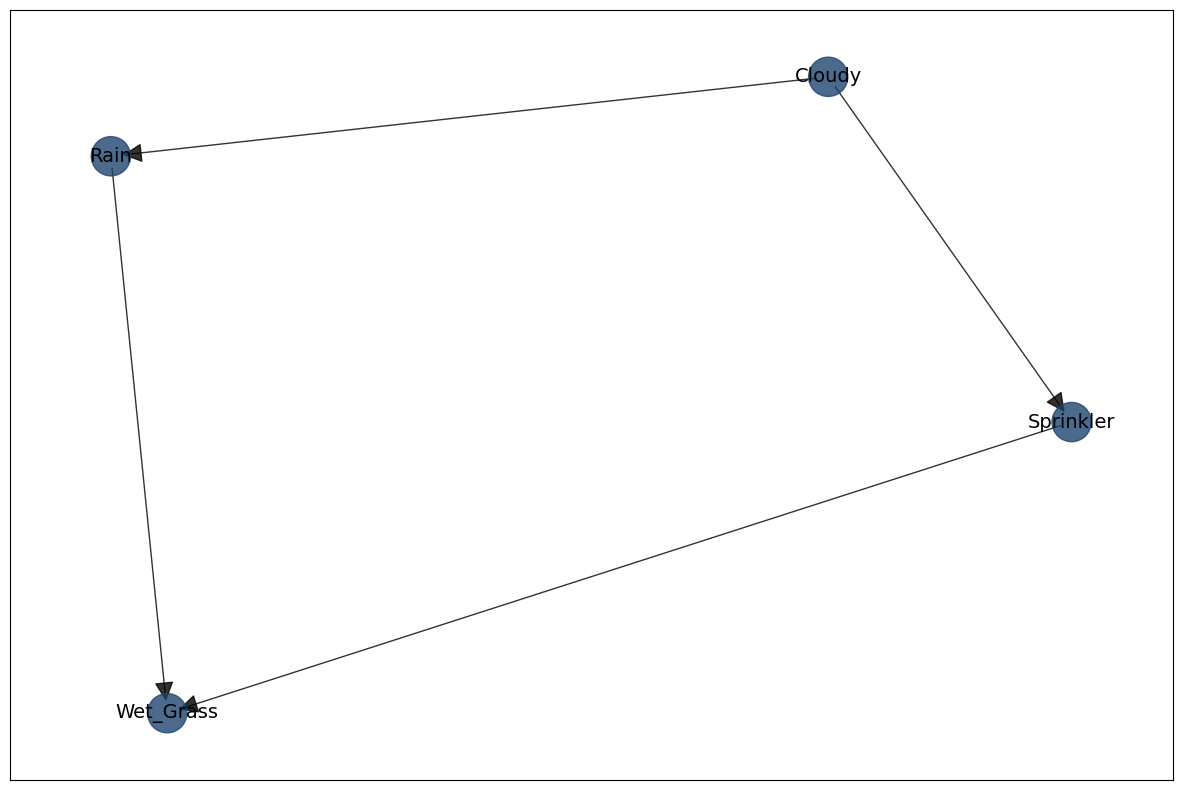

{'fig': <Figure size 1500x1000 with 1 Axes>,
 'ax': <Figure size 1500x1000 with 1 Axes>,
 'pos': {'Cloudy': array([0.37577636, 0.71477573]),
  'Sprinkler': array([ 0.69812114, -0.21552436]),
  'Rain': array([-0.5742329 ,  0.50074863]),
  'Wet_Grass': array([-0.4996646, -1.       ])},
 'G': <networkx.classes.digraph.DiGraph at 0x7f83b80e3970>,
 'node_properties': {'Cloudy': {'node_color': '#1f456e', 'node_size': 800},
  'Sprinkler': {'node_color': '#1f456e', 'node_size': 800},
  'Rain': {'node_color': '#1f456e', 'node_size': 800},
  'Wet_Grass': {'node_color': '#1f456e', 'node_size': 800}},
 'edge_properties': {('Cloudy', 'Sprinkler'): {'color': '#000000',
   'weight': 1},
  ('Cloudy', 'Rain'): {'color': '#000000', 'weight': 1},
  ('Sprinkler', 'Wet_Grass'): {'color': '#000000', 'weight': 1},
  ('Rain', 'Wet_Grass'): {'color': '#000000', 'weight': 1}}}

In [46]:
# plot the model
bn.plot(model)

In [50]:
# print out CPDs
bn.parameter_learning.fit(model, df)

[bnlearn] >Parameter learning> Computing parameters using [bayes]
[bnlearn] >Converting [<class 'pgmpy.base.DAG.DAG'>] to BayesianNetwork model.
[bnlearn] >Converting adjmat to BayesianNetwork.
[bnlearn] >CPD of Cloudy:
+-----------+-------+
| Cloudy(0) | 0.494 |
+-----------+-------+
| Cloudy(1) | 0.506 |
+-----------+-------+
[bnlearn] >CPD of Sprinkler:
+--------------+--------------------+--------------------+
| Cloudy       | Cloudy(0)          | Cloudy(1)          |
+--------------+--------------------+--------------------+
| Sprinkler(0) | 0.4807692307692308 | 0.7075098814229249 |
+--------------+--------------------+--------------------+
| Sprinkler(1) | 0.5192307692307693 | 0.2924901185770751 |
+--------------+--------------------+--------------------+
[bnlearn] >CPD of Rain:
+---------+--------------------+---------------------+
| Cloudy  | Cloudy(0)          | Cloudy(1)           |
+---------+--------------------+---------------------+
| Rain(0) | 0.6518218623481782 | 0.3369

{'model': <pgmpy.models.BayesianNetwork.BayesianNetwork at 0x7f83b8138e80>,
 'adjmat': target     Cloudy  Sprinkler   Rain  Wet_Grass
 source                                        
 Cloudy      False       True   True      False
 Sprinkler   False      False  False       True
 Rain        False      False  False       True
 Wet_Grass   False      False  False      False,
 'config': {'verbose': 3, 'method': 'bayes', 'n_jobs': -1},
 'model_edges': [('Cloudy', 'Sprinkler'),
  ('Cloudy', 'Rain'),
  ('Sprinkler', 'Wet_Grass'),
  ('Rain', 'Wet_Grass')],
 'structure_scores': {'k2': -1952.7499005180116,
  'bds': -1961.36196289961,
  'bic': -1953.219110059786,
  'bdeu': -1954.4304910940107},
 'independence_test': None}

In [51]:
# Save model as file for reuse
bn.save(model, filepath="./bn_model", overwrite=True)

[pypickle] Pickle file saved: [/home/jqi/Workspace/comma/notebooks/bn_model.pkl]


True